In [ ]:
import os
import numpy as np
import sys
import pandas as pd
import torch.cuda
from openpyxl import load_workbook, Workbook

notebook_dir = os.path.abspath('')

root_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

from stable_baselines3 import SAC
from aml_project.environments.lettuce_greenhouse import LettuceGreenhouse
from aml_project.common.plot_gh_variables import create_trajectory_figure, plot_trajectory
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from aml_project.environments.AblatedLettuceGreenhouse import AblatedLettuceGreenhouse


# reward_coefs = [c_r1 (growth), c_r_co2_2 (CO2 in-bounds)]
custom_reward_coefs = np.array([5.0, 0.05])

# penalty_coefs = [c_r_u1 (CO2), c_r_u2 (Vent), c_r_u3 (Heat), c_r_co2_1 (CO2 bounds), c_r_T1 (Temp low), c_r_T2 (Temp high), c_r_RH (RH), c_r_co2_vent (CO2+vent), c_coact (heat+vent action)]
custom_penalty_coefs = np.array([4.5360e-4, 0.0075, 8.5725e-4,  # u1, u2, u3
                           0.5,                             # c_r_co2_1
                           0.6, 0.3,                        # c_r_T1, c_r_T2
                           0.5,                            # c_r_RH
                           0.001, 0.06])                     # c_r_co2_vent, c_coact
weather_file = root_dir + r"\aml_project\environments\weather\outdoorWeatherWurGlas2014.mat"

# Define the ablation runs: name -> which actions the RL agent controls
ABLATIONS = {
    "full":        [0, 1, 2],
    "co2_only":    [0],
    "vent_only":   [1],
    "heating_only":[2],
    "heuristic_only": []
}

results = {}

for run_name, active in ABLATIONS.items():
    print(f"\n{'='*40}")
    print(f"Run: {run_name}  |  RL controls: {active}")
    print('='*40)

    # --- Build env ---
    base_env = AblatedLettuceGreenhouse(
        active_actions=active,
        weather_data_dir=weather_file,
        reward_coefs=custom_reward_coefs,
        penalty_coefs=custom_penalty_coefs,
        n_days=40
    )
    vec_env    = DummyVecEnv([lambda e=base_env: e])
    train_env  = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=10.)

    # --- Train ---
    if len(active) > 0:
        model = SAC("MlpPolicy", train_env, verbose=0, learning_rate=1e-3,
                    batch_size=64, device='cpu')
        model.learn(total_timesteps=100)
        model.save(f"sac_{run_name}")
    else:
        # Skip training for pure heuristics
        model = None

    # --- Evaluate ---
    obs  = train_env.reset()
    done = False
    k    = 0
    total_reward = 0.0
    info = {}
    
    # --- ADDED: Arrays to track trajectories ---
    N_steps = base_env.N
    ny = base_env.ny
    y_traj = np.zeros((ny, N_steps))
    u_traj = np.zeros((3, N_steps))

    while not done and k < base_env.N:
        if model is not None:
            action, _ = model.predict(obs, deterministic=True)
        else:
            action = np.zeros((1, 0), dtype=np.float32)

        # Record physical state BEFORE step (get_original_obs returns unnormalized state)
        y_traj[:, k] = train_env.get_original_obs()[0][:ny]

        obs, reward, dones, infos = train_env.step(action)
        done  = dones[0]
        info  = infos[0]
        total_reward += reward[0]
        
        # Record the physical action applied 
        u_traj[:, k] = base_env.prev_action
        
        k += 1
        
    # Trim excess if episode ended early
    y_traj = y_traj[:, :k]
    u_traj = u_traj[:, :k]

    # --- Summarise ---
    revenue      = np.sum(info["revenue"])
    co2_cost     = np.sum(info["co2_cost"])
    heating_cost = np.sum(info["heating_cost"])
    profit       = revenue - co2_cost - heating_cost
    penalty      = np.sum(info["penalty"])

    # --- ADDED: Save 'y' and 'u' to results ---
    results[run_name] = {
        "revenue":      revenue,
        "co2_cost":     co2_cost,
        "heating_cost": heating_cost,
        "profit":       profit,
        "penalty":      penalty,
        "total_reward": total_reward,
        "y":            y_traj,
        "u":            u_traj
    }

    print(f"  Revenue      : {revenue:.2f}")
    print(f"  CO2 cost     : {co2_cost:.2f}")
    print(f"  Heating cost : {heating_cost:.2f}")
    print(f"  Profit       : {profit:.2f}")
    print(f"  Penalty      : {penalty:.2f}")
    print(f"  Total reward : {total_reward:.2f}")


Run: full  |  RL controls: [0, 1, 2]
  Revenue      : 1570.28
  CO2 cost     : 1.74
  Heating cost : 93.10
  Profit       : 1475.44
  Penalty      : -136893.63
  Total reward : -135418.19

Run: co2_only  |  RL controls: [0]
  Revenue      : 1413.45
  CO2 cost     : 1.22
  Heating cost : 372.86
  Profit       : 1039.37
  Penalty      : -272699.77
  Total reward : -271660.40

Run: vent_only  |  RL controls: [1]
  Revenue      : -225332407773.34
  CO2 cost     : 1.09
  Heating cost : 216.97
  Profit       : -225332407991.40
  Penalty      : -70748351322566025216.00
  Total reward : -70748352766176985088.00

Run: heating_only  |  RL controls: [2]
  Revenue      : 1576.26
  CO2 cost     : 2.02
  Heating cost : 42.81
  Profit       : 1531.43
  Penalty      : -268020.52
  Total reward : -266489.09

Run: heuristic_only  |  RL controls: []
  Revenue      : 1454.28
  CO2 cost     : 2.02
  Heating cost : 372.86
  Profit       : 1079.41
  Penalty      : -275963.44
  Total reward : -274884.03


In [21]:
import pandas as pd

df = pd.DataFrame(results).T
df["profit/|penalty|"] = df["profit"] / df["penalty"].abs()
print(df.round(2).to_string())

                            revenue  co2_cost heating_cost              profit                 penalty            total_reward                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

ValueError: x and y must have same first dimension, but have shapes (3840,) and (2077,)

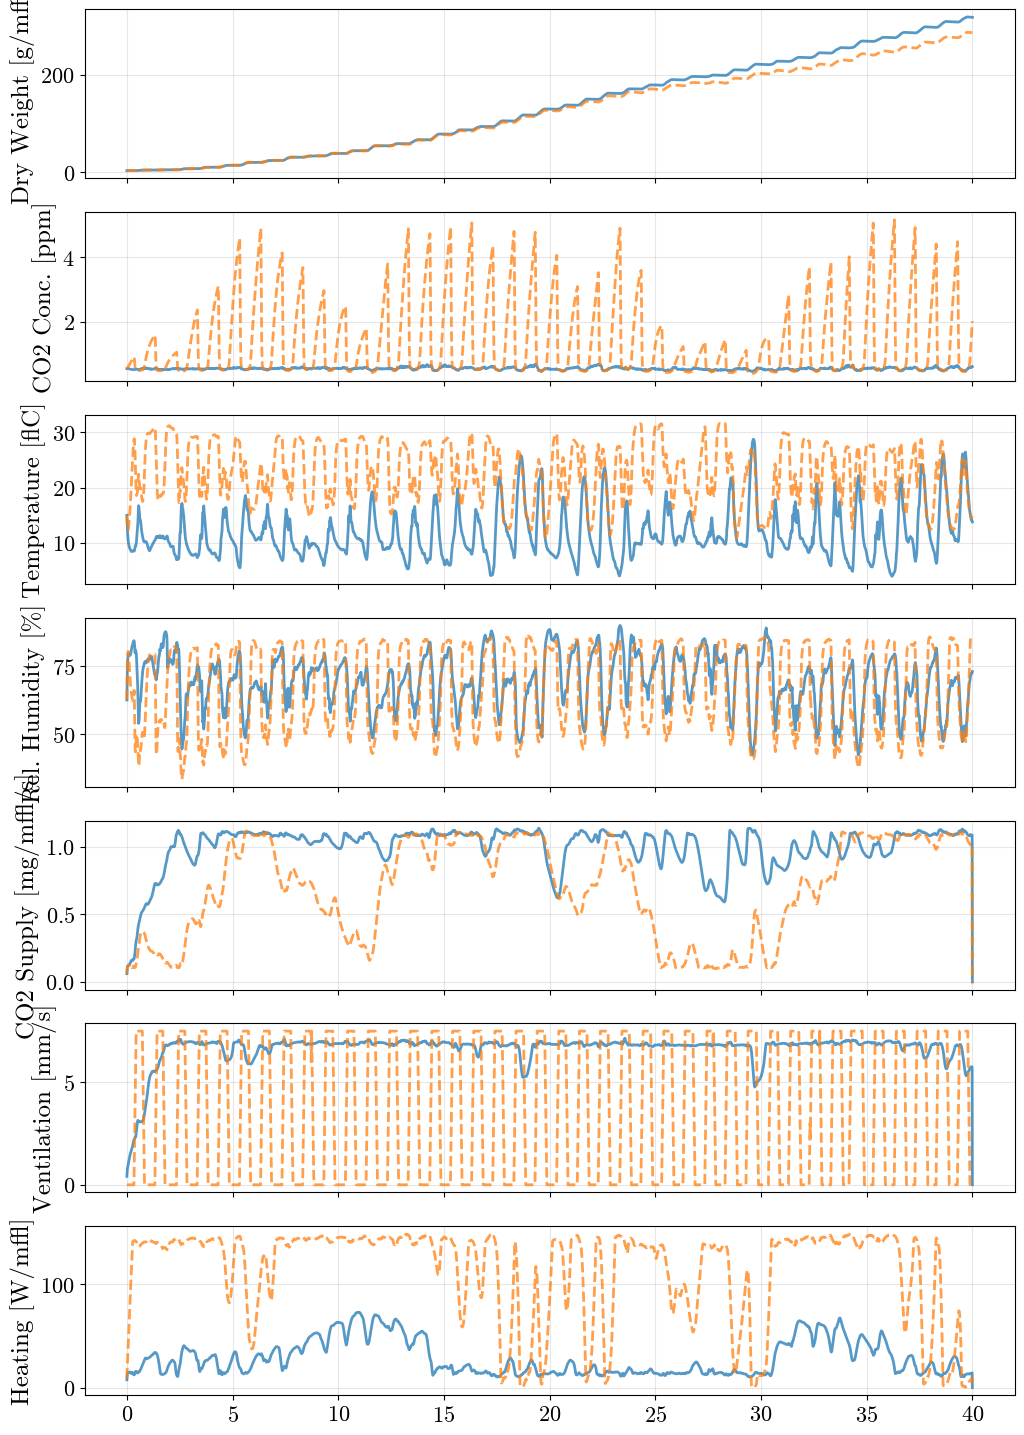

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_runs_comparison(results_dict, start_day=0, end_day=None, total_days=40):
    """
    Plots the trajectories of multiple runs on the same figure.
    """
    # Extract the 'y' array from the first run to get the total number of steps (N)
    first_key = list(results_dict.keys())[0]
    sample_y = results_dict[first_key]["y"]
    
    N = sample_y.shape[1] # Total steps in the simulation
    steps_per_day = N / total_days
    
    # Determine the slice indices
    idx_start = int(start_day * steps_per_day)
    if end_day is None:
        idx_end = N
        end_day = total_days
    else:
        idx_end = int(end_day * steps_per_day)
        
    # Create time arrays in days
    t = np.linspace(start_day, end_day, idx_end - idx_start)
    
    # Set up a 7-row subplot grid (4 states + 3 actions)
    fig, axes = plt.subplots(7, 1, figsize=(12, 18), sharex=True)
    
    state_labels = ['Dry Weight [g/m²]', 'CO2 Conc. [ppm]', 'Temperature [°C]', 'Rel. Humidity [%]']
    action_labels = ['CO2 Supply [mg/m²/s]', 'Ventilation [mm/s]', 'Heating [W/m²]']
    
    # Use distinct colors and linestyles to maintain readability when lines overlap
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    line_styles = ['-', '--', '-.', ':', '-']
    
    for i, (run_name, data) in enumerate(results_dict.items()):
        y = data['y']  # Measurement states
        u = data['u']  # Control actions
        
        c = colors[i % len(colors)]
        ls = line_styles[i % len(line_styles)]
        
        # 1. Plot the 4 States
        for j in range(4):
            axes[j].plot(t, y[j, idx_start:idx_end], 
                         label=run_name, color=c, linestyle=ls, alpha=0.75, linewidth=2)
            axes[j].set_ylabel(state_labels[j])
            axes[j].grid(True, alpha=0.3)
            
        # 2. Plot the 3 Actions
        for j in range(3):
            axes[4+j].plot(t, u[j, idx_start:idx_end], 
                           label=run_name, color=c, linestyle=ls, alpha=0.75, linewidth=2)
            axes[4+j].set_ylabel(action_labels[j])
            axes[4+j].grid(True, alpha=0.3)
            
    # Format the x-axis and add the shared legend
    axes[-1].set_xlabel("Time (Days)")
    
    # Place legend at the top, spread across columns
    axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), 
                   ncol=len(results_dict), fancybox=True, shadow=True)
    
    plt.suptitle(f"Trajectory Comparison (Day {start_day} to Day {end_day})", y=0.92, fontsize=14, weight='bold')
    
    # Adjust layout to prevent clipping
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

# --- EXAMPLES OF HOW TO USE IT ---

# 1. Plot the entire 40-day run
plot_all_runs_comparison(results, start_day=0, end_day=40)

# 2. Plot a zoomed-in window (e.g., just the first 5 days)
# plot_all_runs_comparison(results, start_day=0, end_day=5)